# PatchTST: Final Training Run

This notebook contains the final training run of our PatchTST model on the
[UCI Electricity Load Diagrams 2011-2014](https://archive.ics.uci.edu/ml/datasets/ElectricityLoadDiagrams20112014)
dataset. The model is trained jointly on two tasks defined on the same data:

1. **Forecasting (regression):** predict the next `pred_len` time steps of
   electricity consumption for all 370 clients given a `lookback` window of
   past consumption.
2. **Weekend classification (binary):** for each time step in the input
   window, predict whether it falls on a weekend.

The architecture, data pipeline and training loop are documented from scratch
in `patchtst.ipynb` and `patchtst_patch_size_experiments.ipynb`. This notebook
uses the best configuration found during the patch-size sweeps and trains it
for more epochs, then performs sanity checks on the resulting model.

## Notebook Layout

1. Setup and paths
2. Experiment configuration
3. Data: dataset class, loading and normalisation
4. Model: RevIN, patch embedding, transformer encoder, dual heads
5. Training and evaluation utilities
6. Final training run
7. Qualitative Sanity Checks
8. 8. Full Evaluation — Per-Channel Metrics & Classification Scores


## 1. Setup

Standard imports plus a few global settings (matplotlib style and the TF32
matmul precision on supported GPUs). Project paths are resolved relative to
the notebook's working directory so the same code runs locally and on a
remote training machine.


In [1]:
from __future__ import annotations

import csv
import math
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from torch import nn
from torch.optim import AdamW

plt.style.use("seaborn-v0_8-whitegrid")
torch.set_float32_matmul_precision("high")

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "dataset" / "LD2011_2014.txt"
RESULTS_PATH = PROJECT_ROOT / "results" / "patchtst_patch_size_results.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset exists: {DATA_PATH.exists()} ({DATA_PATH})")
print(f"Results CSV exists: {RESULTS_PATH.exists()} ({RESULTS_PATH})")


Project root: /workspace/deep_learning
Dataset exists: True (/workspace/deep_learning/dataset/LD2011_2014.txt)
Results CSV exists: True (/workspace/deep_learning/results/patchtst_patch_size_results.csv)


## 2. Experiment Configuration

All hyperparameters live in a single frozen dataclass so the run is fully
described by a single object that can be logged or serialised. The values
below correspond to the best configuration from our patch-size experiments:

- `patch_size=16`, `lookback=256` → 16 patches per series.
- A 3-layer transformer encoder with `embed_dim=128`, 16 heads and a
  256-wide feed-forward block.
- AdamW with `lr=1e-4`, weight decay `0.01`, dropout `0.2`.
- `pred_len=96` (a 24h horizon at 15-minute resolution).

`max_train_batches` and `max_eval_batches` are kept on the config for
compatibility with the experiment runner used in the patch-size sweep but
are not used in this final run — we iterate over the full loaders.


In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    patch_size: int = 16
    lookback: int = 256
    pred_len: int = 96
    train_ratio: float = 0.9
    batch_size: int = 32
    embed_dim: int = 128
    num_layers: int = 3
    num_heads: int = 16
    ff_dim: int = 256
    dropout: float = 0.2
    lr: float = 1e-4
    weight_decay: float = 0.01
    epochs: int = 2
    max_train_batches: int | None = 200
    max_eval_batches: int | None = 150
    seed: int = 42


CFG = ExperimentConfig()
CFG

ExperimentConfig(patch_size=16, lookback=256, pred_len=96, train_ratio=0.9, batch_size=32, embed_dim=128, num_layers=3, num_heads=16, ff_dim=256, dropout=0.2, lr=0.0001, weight_decay=0.01, epochs=2, max_train_batches=200, max_eval_batches=150, seed=42)

## 3. Data

### 3.1 `TimeDataset`

A simple sliding-window dataset over the normalised consumption matrix. Each
sample returns three tensors:

- `x` — `[seq_len, num_channels]` lookback window (370 client series).
- `y` — `[pred_len, num_channels]` forecast target.
- `y_time` — `[seq_len]` boolean weekend flag for the lookback window
  (the auxiliary classification target).

The last column of the input matrix is treated as the weekend label and is
excluded from the consumption tensors.

### 3.2 Loading and normalisation

`load_raw_dataframe` reads the semicolon-separated UCI file and parses the
date index. `split_and_normalize` appends a `time_label` column
(`weekday >= 5`), performs a chronological train/test split, and z-scores
both halves using the **training** statistics only — this avoids leakage
from the test set. A small guard replaces near-zero std values by `1.0` to
keep constant series finite.


In [3]:
class TimeDataset(torch.utils.data.Dataset):
    def __init__(self, data: np.ndarray, seq_len: int = 96, pred_len: int = 96):
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.data = data[:, :-1].astype(np.float32, copy=False)
        self.time_labels = data[:, -1] > 0

    def __len__(self) -> int:
        return max(0, len(self.data) - self.seq_len - self.pred_len + 1)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        y_time = self.time_labels[idx : idx + self.seq_len]
        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(y_time)


def load_raw_dataframe(data_path: Path) -> pd.DataFrame:
    df = pd.read_csv(data_path, sep=";", decimal=",", index_col=0)
    df.index = pd.to_datetime(df.index)
    return df


def split_and_normalize(df: pd.DataFrame, train_ratio: float) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    df["time_label"] = df.index.weekday >= 5
    values = df.to_numpy(dtype=np.float64, copy=True)
    split_idx = int(len(values) * train_ratio)
    train = values[:split_idx]
    test = values[split_idx:]

    mean = train.mean(axis=0, keepdims=True)
    std = train.std(axis=0, keepdims=True)
    std = np.where(std < 1e-6, 1.0, std)

    train_norm = (train - mean) / std
    test_norm = (test - mean) / std
    return train_norm.astype(np.float32), test_norm.astype(np.float32), mean, std


Run the loading and normalisation once with an 80/20 split for the quick
sanity check below. The `PerformanceWarning` from pandas is benign — it
just notes that adding the `time_label` column fragments the frame.


In [ ]:
df = load_raw_dataframe(DATA_PATH)
train, test, mean, std = split_and_normalize(df, 0.8)

Quick check that the weekend column survives normalisation as a proper
binary indicator (two distinct values after standardisation).


In [ ]:
np.unique(train[:, -1])

## 4. Model Architecture

The model follows the PatchTST design (Nie et al., 2023) with two additions
needed for our dual-task setup.

**`RevIN`** — Reversible Instance Normalisation. Per-instance, per-channel
mean/std normalisation applied at the input and inverted at the output. It
lets the transformer see comparable scales across very different clients
and is a standard trick in modern forecasting models.

**`PositionalEncoding`** — classical sinusoidal encoding added to the patch
embeddings.

**`Patching`** — splits each channel into non-overlapping patches of size
`patch_size` and projects them to `embed_dim` with a single 1D convolution.
Channels are processed independently (channel-independent PatchTST), so the
transformer attends across time only within a single series.

**`TimeHead`** — auxiliary head for weekend classification. It pools the
encoder output across channels (mean over the channel axis), projects each
patch back to `patch_size` logits and reshapes them to one logit per input
time step. Sharing the encoder between the two heads gives the model an
explicit signal about weekly seasonality, which we expect to help the
consumption forecast as well.

**`PatchTST`** ties everything together: RevIN → patch embed → positional
encoding → transformer encoder → forecasting head + time-classification
head. The forecasting head is a single linear layer on the flattened
encoder output; the output is denormalised by RevIN before being returned.


In [4]:
class RevIN(nn.Module):
    def __init__(self, eps: float = 1e-5):
        super().__init__()
        self.mean = None
        self.std = None
        self.eps = eps

    def forward(self, x: torch.Tensor, mode: str = "norm") -> torch.Tensor:
        if mode == "norm":
            self.mean = x.mean(dim=1, keepdim=True).detach()
            self.std = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps).detach()
            return (x - self.mean) / self.std
        if mode == "denorm":
            return x * self.std + self.mean
        raise ValueError(f"Unknown RevIN mode: {mode}")


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 100):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(1, max_len, d_model)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)


class Patching(nn.Module):
    def __init__(self, patch_size: int, embed_dim: int):
        super().__init__()
        self.patch = nn.Conv1d(1, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, lookback_len, num_channels = x.shape
        channel_independent = x.permute(0, 2, 1).reshape(batch_size * num_channels, 1, lookback_len)
        return self.patch(channel_independent).permute(0, 2, 1)

class TimeHead(nn.Module):
    def __init__(self, embed_dim, patch_size):
        super().__init__()
        self.embed_dim = embed_dim
        self.patch_size = patch_size
        self.proj = nn.Linear(embed_dim, patch_size)

    def forward(self, x): # [B, C, P, E]
        B, C, P, E = x.shape
        return self.proj(x.mean(dim=1)).reshape(B, P * self.patch_size)


class PatchTST(nn.Module):
    def __init__(
        self,
        lookback_len: int,
        pred_len: int,
        patch_size: int,
        embed_dim: int,
        num_layers: int = 2,
        num_heads: int = 4,
        ff_dim: int = 128,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.lookback_len = lookback_len
        self.pred_len = pred_len
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.revin = RevIN()
        self.patching = Patching(patch_size, embed_dim)

        patch_count = ((lookback_len - patch_size) // patch_size) + 1
        self.pos_encoding = PositionalEncoding(embed_dim, dropout=dropout, max_len=patch_count)
        encoder_layer = nn.TransformerEncoderLayer(
            embed_dim,
            num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.head = nn.Linear(patch_count * embed_dim, pred_len)
        self.time_head = TimeHead(self.embed_dim, self.patch_size)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        batch_size, _, num_channels = x.shape
        x = self.revin(x)
        patched = self.patching(x)
        encoded = self.encoder(self.pos_encoding(patched))
        out = self.head(encoded.reshape(batch_size, num_channels, -1)).permute(0, 2, 1)
        time_head_input = encoded.reshape(batch_size, num_channels, -1, self.embed_dim)
        return self.revin(out, "denorm"), self.time_head(time_head_input)


Shape sanity check on a tiny dummy input. With `lookback=128`, `pred_len=96`,
`patch_size=4`, batch size 2 and 7 channels, the time-classification head
must return logits of shape `[2, 128]` (one per input time step).


In [ ]:
p = PatchTST(128, 96, 4, 64)
p(torch.rand(2, 128, 7))[1].shape

## 5. Training and Evaluation

### 5.1 Device selection

Pick CUDA when available, then Apple's MPS backend, then CPU.

### 5.2 `run_epoch`

One training pass over the loader with the joint loss

$$\mathcal{L} = \mathrm{MSE}(\hat y, y) + \mathrm{BCE}(\hat t, t),$$

where the second term is the weekend-classification loss. Gradients are
clipped to a global norm of `1.0` for stability, which we found was needed
in the early epochs.

### 5.3 `evaluate`

Runs the model in eval mode and accumulates squared error, absolute error
and classification accuracy across the whole loader. Returns
`(mse, mae, rmse, acc)` so we can report all four numbers without iterating
the loader twice.


In [5]:
def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def run_epoch(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    device: torch.device,
    optimizer: torch.optim.Optimizer,
) -> float:
    model.train()
    loss_fn = nn.MSELoss()
    cls_fn = nn.BCEWithLogitsLoss()
    total_loss = 0.0
    count = 0

    for x, y, y_t in tqdm(loader):
        x = x.to(device)
        y = y.to(device)
        y_t = y_t.to(device)

        optimizer.zero_grad(set_to_none=True)
        pred, pred_time = model(x)
        loss = loss_fn(pred, y) + cls_fn(pred_time, y_t.float())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        count += 1

    return total_loss / max(count, 1)

@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: torch.utils.data.DataLoader,
    device: torch.device,
) -> tuple[float, float, float]:
    model.eval()
    total_squared_error = 0.0
    total_absolute_error = 0.0
    total_points = 0
    cls_correct = 0
    cls_total = 0

    for batch_idx, (x, y, y_t) in enumerate(loader):
        x = x.to(device)
        y = y.to(device)
        y_t = y_t.to(device)
        pred, pred_t = model(x)
        diff = pred - y

        total_squared_error += torch.sum(diff * diff).item()
        total_absolute_error +=  torch.sum(torch.abs(diff)).item()
        total_points += diff.numel()

        cls_correct += ((nn.functional.sigmoid(pred_t) > 0.5) == y_t).sum().item()
        cls_total += pred_t.numel()

    mse = total_squared_error / max(total_points, 1)
    mae = total_absolute_error / max(total_points, 1)
    rmse = math.sqrt(mse)
    acc = cls_correct / cls_total
    return mse, mae, rmse, acc

## 6. Final Training Run

Build the loaders, instantiate the model with the chosen configuration and
train for `CFG.epochs` epochs. After each epoch we evaluate on the held-out
test split and print train loss, test MSE, test MAE and test classification
accuracy.

On a single CUDA GPU the run takes roughly 16 minutes per epoch with the
default loader configuration (`batch_size=32`, `num_workers=4`).


In [13]:
from torch.utils.data import DataLoader
from tqdm import tqdm

device = choose_device()
print(f"Training on: {device}")

df = load_raw_dataframe(DATA_PATH)
train_data, test_data, _, _ = split_and_normalize(df, CFG.train_ratio)
train_dataset = TimeDataset(train_data, seq_len=CFG.lookback, pred_len=CFG.pred_len)
test_dataset  = TimeDataset(test_data,  seq_len=CFG.lookback, pred_len=CFG.pred_len)

train_loader = DataLoader(
    train_dataset, batch_size=CFG.batch_size,
    shuffle=True, drop_last=True, num_workers=4,
)
test_loader = DataLoader(
    test_dataset, batch_size=CFG.batch_size,
    shuffle=False, drop_last=False, num_workers=4,
)
print(f"Train windows: {len(train_dataset):,}   Test windows: {len(test_dataset):,}")

model = PatchTST(
    lookback_len=CFG.lookback,
    pred_len=CFG.pred_len,
    patch_size=CFG.patch_size,
    embed_dim=CFG.embed_dim,
    num_layers=CFG.num_layers,
    num_heads=CFG.num_heads,
    ff_dim=CFG.ff_dim,
    dropout=CFG.dropout,
).to(device)
optimizer = AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

print()
print(f"{'Epoch':>5}  {'Train loss':>12}  {'Test MSE':>10}  "
      f"{'Test MAE':>10}  {'Test RMSE':>10}  {'Weekend acc':>12}")
print("-" * 68)
for epoch in range(1, CFG.epochs + 1):
    train_loss = run_epoch(model, train_loader, device, optimizer)
    mse, mae, rmse, acc = evaluate(model, test_loader, device)
    print(f"{epoch:>5}  {train_loss:>12.4f}  {mse:>10.4f}  "
          f"{mae:>10.4f}  {rmse:>10.4f}  {acc:>11.4f}")


Training on: cuda


/tmp/ipykernel_10420/868202153.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["time_label"] = df.index.weekday >= 5


Train windows: 125,879   Test windows: 13,675
Model parameters: 598,384

Epoch    Train loss    Test MSE    Test MAE   Test RMSE   Weekend acc
--------------------------------------------------------------------


100%|██████████| 3933/3933 [09:32<00:00,  6.86it/s]


    1        0.5822      0.1658      0.2490      0.4072       0.8954


100%|██████████| 3933/3933 [09:33<00:00,  6.86it/s]


    2        0.3475      0.1617      0.2448      0.4021       0.9179


Model summary: number of parameters and the device used for training.
Both are printed above; this cell is a quick check that `model` and
`device` are in scope for the evaluation cells below.


In [14]:
print(f"Device: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Device: cuda
Parameters: 598,384


## 7. Qualitative Sanity Checks

We inspect the first window of the test set to get an intuitive feel for
model behaviour before looking at aggregate metrics. Three things are
visualised:

1. **Forecast vs. ground truth for three representative clients.**
   Clients are selected at the 10th, 50th and 90th percentile of
   per-channel MSE, giving a view of model quality across the range of
   easy, typical and harder series.
2. **Per-channel MSE across all 370 clients.** A bar chart showing how
   forecast error is distributed across the client population, with the
   three selected clients marked.
3. **Weekend probability vs. ground-truth label.** The sigmoid-activated
   output of the time-classification head plotted against the true
   weekend flag, showing whether the model has learnt the weekly
   periodicity.


Clients selected for visualisation:
  low MSE (10th pct)            client 109  MSE 0.0313
  median MSE (50th pct)         client 260  MSE 0.0912
  high MSE (90th pct)           client   9  MSE 0.3132


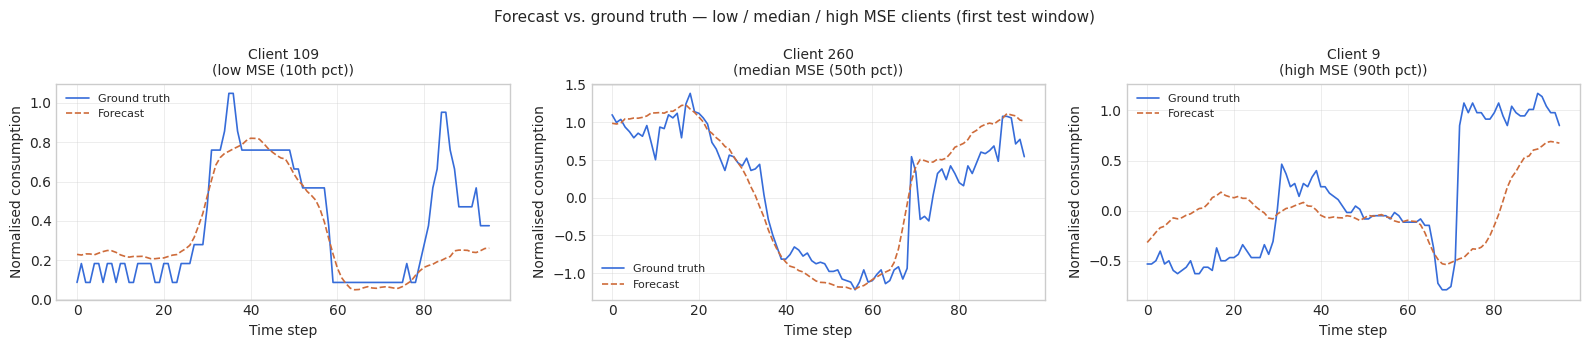

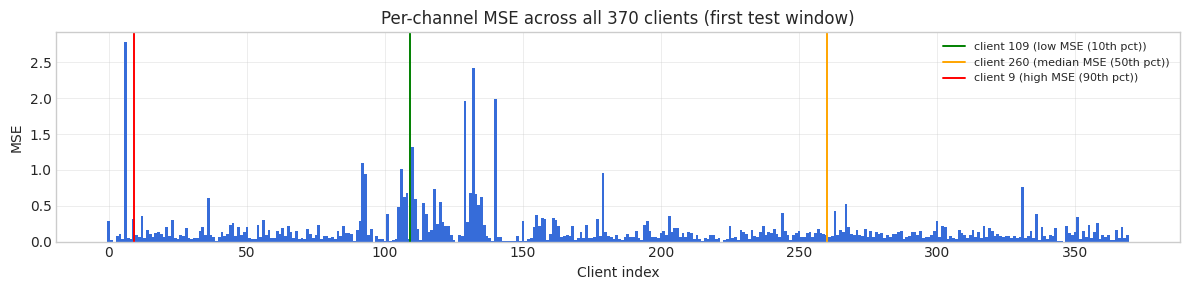

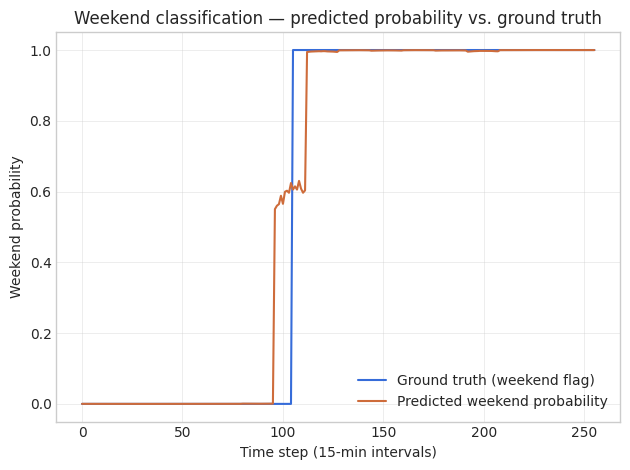

In [15]:
dataset_test = TimeDataset(test_data, seq_len=CFG.lookback, pred_len=CFG.pred_len)

x, y, y_t = dataset_test[0]
with torch.no_grad():
    pred, pred_t = model(x.unsqueeze(0).to(device))
pred   = pred.squeeze(0).cpu()
pred_t = pred_t.cpu()

channel_mse = (pred - y).pow(2).mean(dim=0).detach()

# Pick three representative clients by percentile of per-channel MSE
order = channel_mse.argsort()  # indices sorted low -> high MSE
n = len(order)
showcase = {
    "low MSE (10th pct)":    order[n // 10].item(),
    "median MSE (50th pct)": order[n // 2].item(),
    "high MSE (90th pct)":   order[int(n * 0.9)].item(),
}
print("Clients selected for visualisation:")
for label, idx in showcase.items():
    print(f"  {label:<28}  client {idx:>3}  MSE {channel_mse[idx].item():.4f}")

# 1) Forecast vs. ground truth — one sub-plot per selected client
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5), sharey=False)
for ax, (label, idx) in zip(axes, showcase.items()):
    ax.plot(y[:, idx].numpy(), label='Ground truth', linewidth=1.2)
    ax.plot(pred[:, idx].numpy(), label='Forecast', linewidth=1.2, linestyle='--')
    ax.set_title(f'Client {idx}\n({label})', fontsize=10)
    ax.set_xlabel('Time step')
    ax.set_ylabel('Normalised consumption')
    ax.legend(fontsize=8)
fig.suptitle('Forecast vs. ground truth — low / median / high MSE clients'
             ' (first test window)', fontsize=11)
plt.tight_layout()
plt.show()

# 2) Per-channel MSE bar chart — full population with selected clients marked
plt.figure(figsize=(12, 3))
plt.bar(range(n), channel_mse.numpy(), width=1.0)
colors = ['green', 'orange', 'red']
for (label, idx), color in zip(showcase.items(), colors):
    plt.axvline(idx, color=color, linewidth=1.4, label=f'client {idx} ({label})')
plt.title('Per-channel MSE across all 370 clients (first test window)')
plt.xlabel('Client index')
plt.ylabel('MSE')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 3) Weekend classification — predicted probability vs. ground-truth label
plt.figure()
plt.plot(y_t.numpy(), label='Ground truth (weekend flag)', linewidth=1.5)
plt.plot(torch.sigmoid(pred_t.squeeze(0)).numpy(),
         label='Predicted weekend probability', linewidth=1.5)
plt.title('Weekend classification — predicted probability vs. ground truth')
plt.xlabel('Time step (15-min intervals)')
plt.ylabel('Weekend probability')
plt.legend()
plt.tight_layout()
plt.show()


### 7.1 Scalar metrics on the full test set

Re-run `evaluate` over the complete test loader to confirm the numbers
match the final training-loop row above. Returns `(MSE, MAE, RMSE,
weekend accuracy)` — the same four metrics logged during training.


In [16]:
mse_s, mae_s, rmse_s, acc_s = evaluate(model, test_loader, device)
print(f"Test MSE:          {mse_s:.4f}")
print(f"Test MAE:          {mae_s:.4f}")
print(f"Test RMSE:         {rmse_s:.4f}")
print(f"Weekend accuracy:  {acc_s:.4f}")


Test MSE:          0.1617
Test MAE:          0.2448
Test RMSE:         0.4021
Weekend accuracy:  0.9179


## 8. Full Evaluation — Per-Channel Metrics & Classification Scores

The simple `evaluate` function above aggregates everything into four
scalars. Here we compute a richer set of metrics:

- **Per-channel MSE / MAE / RMSE** across all 370 clients, giving a
  per-client breakdown of where the model performs best and worst.
- **Binary classification metrics** (accuracy, precision, recall, F1)
  for the weekend-detection head, using `torchmetrics` for numerically
  stable online accumulation across the full test loader.

The results are collected into a tidy `eval_scores` DataFrame — one row
per client — suitable for further analysis or export.


In [17]:
from torchmetrics.classification import Accuracy, F1Score, Recall, Precision


def full_eval(model, loader, device):
    """Per-channel MSE/MAE/RMSE over the full loader plus binary classification
    scores (accuracy, precision, recall, F1) for the weekend-detection head.

    The weekend head outputs raw logits, so sigmoid is applied before passing
    predictions to torchmetrics (threshold=0.5 on probabilities)."""
    model.eval()
    total_squared_error  = torch.zeros(370)
    total_absolute_error = torch.zeros(370)
    total_points = 0
    accuracy  = Accuracy("binary", threshold=0.5).to(device)
    f1        = F1Score("binary",  threshold=0.5).to(device)
    recall    = Recall("binary",   threshold=0.5).to(device)
    precision = Precision("binary", threshold=0.5).to(device)

    with torch.no_grad():
        for x, y, y_t in loader:
            x, y, y_t = x.to(device), y.to(device), y_t.to(device)
            pred, pred_t = model(x)

            # torchmetrics expects probabilities in [0,1] and integer labels
            prob_t = torch.sigmoid(pred_t).flatten()
            lbl_t  = y_t.flatten().long()
            accuracy.update(prob_t,  lbl_t)
            f1.update(prob_t,        lbl_t)
            recall.update(prob_t,    lbl_t)
            precision.update(prob_t, lbl_t)

            diff = pred - y
            total_squared_error  += diff.pow(2).sum(dim=(0, 1)).cpu()
            total_absolute_error += diff.abs().sum(dim=(0, 1)).cpu()
            total_points += diff.shape[0] * diff.shape[1]

    mse  = total_squared_error  / max(total_points, 1)
    mae  = total_absolute_error / max(total_points, 1)
    rmse = torch.sqrt(mse)
    return (
        mse, mae, rmse,
        accuracy.compute().item(),
        f1.compute().item(),
        recall.compute().item(),
        precision.compute().item(),
    )


mse, mae, rmse, acc, f1_score, recall_score, precision_score = full_eval(
    model, test_loader, device
)

# --- Weekend classification scores ---
print("Weekend classification (test set):")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {precision_score:.4f}")
print(f"  Recall:    {recall_score:.4f}")
print(f"  F1:        {f1_score:.4f}")
print()

# --- Per-channel forecasting metrics ---
pd.set_option("display.float_format", "{:.6f}".format)
eval_scores = pd.DataFrame(
    {"mse": mse.numpy(), "mae": mae.numpy(), "rmse": rmse.numpy()},
    index=pd.RangeIndex(370, name="client"),
)

print("Distribution of per-channel RMSE across all 370 clients:")
display(eval_scores["rmse"].describe().to_frame().T)

print("\n5 best clients by RMSE:")
display(eval_scores.nsmallest(5, "rmse"))

print("\n5 hardest clients by RMSE:")
display(eval_scores.nlargest(5, "rmse"))


Weekend classification (test set):
  Accuracy:  0.9179
  Precision: 0.8376
  Recall:    0.8907
  F1:        0.8633

Distribution of per-channel RMSE across all 370 clients:


,count,mean,std,min,25%,50%,75%,max
rmse,370.000000,0.357143,0.184938,0.000114,0.258938,0.306901,0.376367,1.387168



5 best clients by RMSE:


,mse,mae,rmse
client,,,
222,0.000000,0.000092,0.000114
2,0.001231,0.019316,0.035091
146,0.004655,0.041600,0.068225
147,0.008791,0.063581,0.093763
144,0.008905,0.064992,0.094365



5 hardest clients by RMSE:


,mse,mae,rmse
client,,,
132,1.924236,0.876113,1.387168
92,1.526099,0.758923,1.235354
129,1.341844,0.764757,1.158380
365,1.135795,0.773631,1.065737
108,1.111213,0.735144,1.054141
